# 1. READING AND DISPLAYING IMAGES IN PYTHON

## 1.1 Lectura y propiedades básicas de una imagen

¿Cómo lee Python una imagen con Scikit-Image?

Usamos la función io.imread('nombre_archivo'). Al leer la imagen, Python no guarda "píxeles visuales", sino una matriz numérica de NumPy:   

- Imagen en escala de grises: Se guarda como una matriz 2D de dimensiones $N \times M$, donde $N$ es el alto (eje $Y$) y $M$ el ancho (eje $X$).   
- Imagen a color: Se guarda como una matriz 3D de dimensiones $N \times M \times 3$, donde la tercera dimensión tiene 3 canales: Rojo (R), Verde (G) y Azul (B).   

¿Qué información debemos inspeccionar?   

- Dimensiones (img.shape): Nos dirá $(N, M)$ si es escala de grises o $(N, M, 3)$ si es color.   
- Rango de valores (img.min() y img.max()): Típicamente, si el formato es entero sin signo de 8 bits (uint8), los valores de intensidad van del $0$ (negro puro) al $255$ (blanco puro).   
- Visualización (plt.imshow): Para mostrar la imagen. En matplotlib, si es una imagen de 2 dimensiones (escala de grises), debemos añadir explícitamente el parámetro cmap='gray'. De lo contrario, matplotlib aplicará por defecto un mapa de calor falso (pseudocolor verde/amarillo).

Dimensiones de la imagen (N x M): (519, 880)
¿Es una imagen a color?: False
Rango de valores de los píxeles: Min = 0, Max = 255


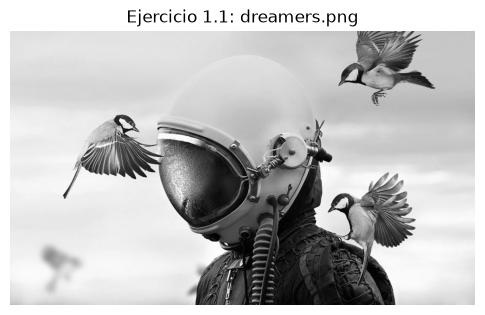

In [2]:
import matplotlib.pyplot as plt
from skimage import io

# 1. Leer la imagen 'dreamers.png'
img_dreamers = io.imread('dreamers.png')

# 2. Inspeccionar sus propiedades
shape = img_dreamers.shape
min_val = img_dreamers.min()
max_val = img_dreamers.max()

# Determinar si es color o escala de grises según sus dimensiones (ndim)
is_color = img_dreamers.ndim == 3 and shape[2] == 3

print(f"Dimensiones de la imagen (N x M): {shape}")
print(f"¿Es una imagen a color?: {is_color}")
print(f"Rango de valores de los píxeles: Min = {min_val}, Max = {max_val}")

# 3. Mostrar la imagen en escala de grises
plt.figure(figsize=(6, 6))
# Usamos cmap='gray' si la matriz tiene 2 dimensiones
if not is_color:
    plt.imshow(img_dreamers, cmap='gray')
else:
    plt.imshow(img_dreamers)

plt.title('Ejercicio 1.1: dreamers.png')
plt.axis('off')
plt.show()

## 1.2 Manipulación de componentes de color

Una imagen RGB es una matriz 3D (N, M, 3). En Python (indexación desde 0):   

- peppers[:, :, 0] es la matriz 2D del canal Rojo (Red).
- peppers[:, :, 1] es la matriz 2D del canal Verde (Green).
- peppers[:, :, 2] es la matriz 2D del canal Azul (Blue).

El ejercicio nos pide mostrar la componente roja de tres formas distintas:   

Como matriz 2D en escala de grises 
Extraemos peppers[:, :, 0] y la mostramos con cmap='gray'.   
¿Cómo comprobar visualmente si es correcta? En la imagen original, los pimientos rojos deben verse muy brillantes (blancos o gris claro) en el canal R, mientras que los pimientos verdes y el fondo oscuro deben verse más oscuros.

En pseudocolor (mapa de colores jet):

Usamos la misma matriz 2D del canal R pero cambiando la paleta visual a cmap='jet'. Esto asignará colores cálidos (rojo/amarillo) a las zonas de alta intensidad y colores fríos (azul) a las zonas de baja intensidad.   

Como imagen a color real (True Color) modificada:

Creamos una copia de la imagen a color de 3 dimensiones (N, M, 3) y ponemos a cero los canales Verde y Azul (peppers_red_only[:, :, 1] = 0 y peppers_red_only[:, :, 2] = 0). Al mostrarla con plt.imshow, veremos la foto original teñida completamente de rojo. 

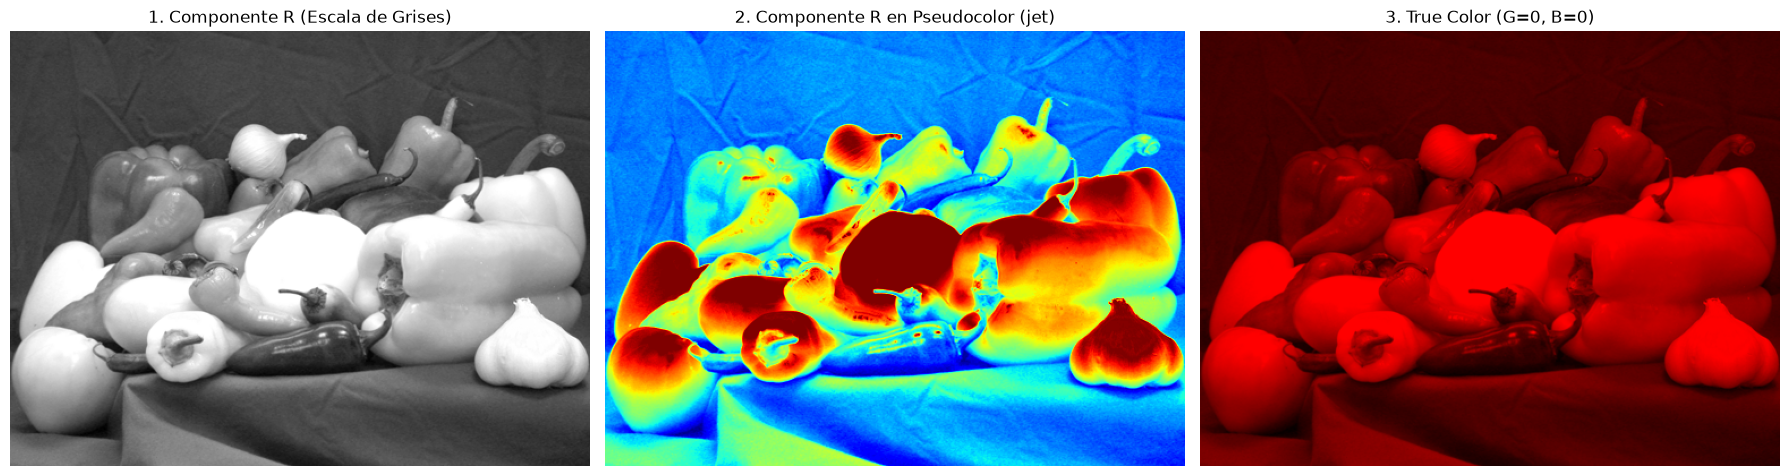

In [3]:
# 1. Leer la imagen 'peppers.png'
img_peppers = io.imread('peppers.png')

# Si la imagen se lee con 4 canales (RGBA), dejamos solo los 3 primeros (RGB)
if img_peppers.ndim == 3 and img_peppers.shape[2] == 4:
    img_peppers = img_peppers[:, :, :3]

# 2. Extraer la componente roja como matriz 2D
red_channel_2d = img_peppers[:, :, 0]

# 3. Crear una copia de la imagen a color y poner G y B a cero
red_true_color = img_peppers.copy()
red_true_color[:, :, 1] = 0  # Canal Verde = 0
red_true_color[:, :, 2] = 0  # Canal Azul = 0

# 4. Visualización en una sola figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# A. Componente R en Escala de Grises
axes[0].imshow(red_channel_2d, cmap='gray')
axes[0].set_title('1. Componente R (Escala de Grises)')
axes[0].axis('off')

# B. Componente R en Pseudocolor (jet)
axes[1].imshow(red_channel_2d, cmap='jet')
axes[1].set_title('2. Componente R en Pseudocolor (jet)')
axes[1].axis('off')

# C. Imagen True Color solo con canal R (G=0, B=0)
axes[2].imshow(red_true_color)
axes[2].set_title('3. True Color (G=0, B=0)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# 2. COLOR REPRESENTATION: RGB AND HSV

## 2.1 Análisis de los Espacios de Color RGB y HSV

Componentes RGB:
- R (Red), G (Green), B (Blue) representan directamente la cantidad de luz roja, verde y azul de cada píxel.   
- Los mostraremos por separado en una sola figura usando plt.subplot.   

Espacio HSV (Hue, Saturation, Value):
- H (Hue / Tono): Representa el ángulo del color puro (rojo, verde, azul, amarillo, etc.). En skimage.color.rgb2hsv, los valores de $H$ están normalizados en el rango $[0, 1]$.    El valor $H = 0.0$ (o $1.0$, ya que es circular de $0^\circ$ a $360^\circ$) representa el color Rojo.
- S (Saturation / Saturación): Indica la pureza o intensidad del color (rango $[0, 1]$). Un valor de $0$ es gris neutro (sin color) y $1$ es color puro saturado.   
- V (Value / Brillo): Representa el brillo general del píxel (rango $[0, 1]$). $0$ es negro absoluto y $1$ es brillo máximo.   

¿Qué rango tiene la componente H? 

En skimage, el rango de $H$ es $[0.0, 1.0]$ (mapeado desde $0^\circ$ a $360^\circ$).   

¿Qué valor de H representa el rojo? 

El valor $0.0$ (o cercano a $1.0$).   ¿Cómo codifica HSV el color blanco? El blanco no tiene tono ni color puro saturado. Por lo tanto, el blanco se representa con Saturación $S = 0$ y Brillo $V = 1$ (con cualquier valor de $H$).

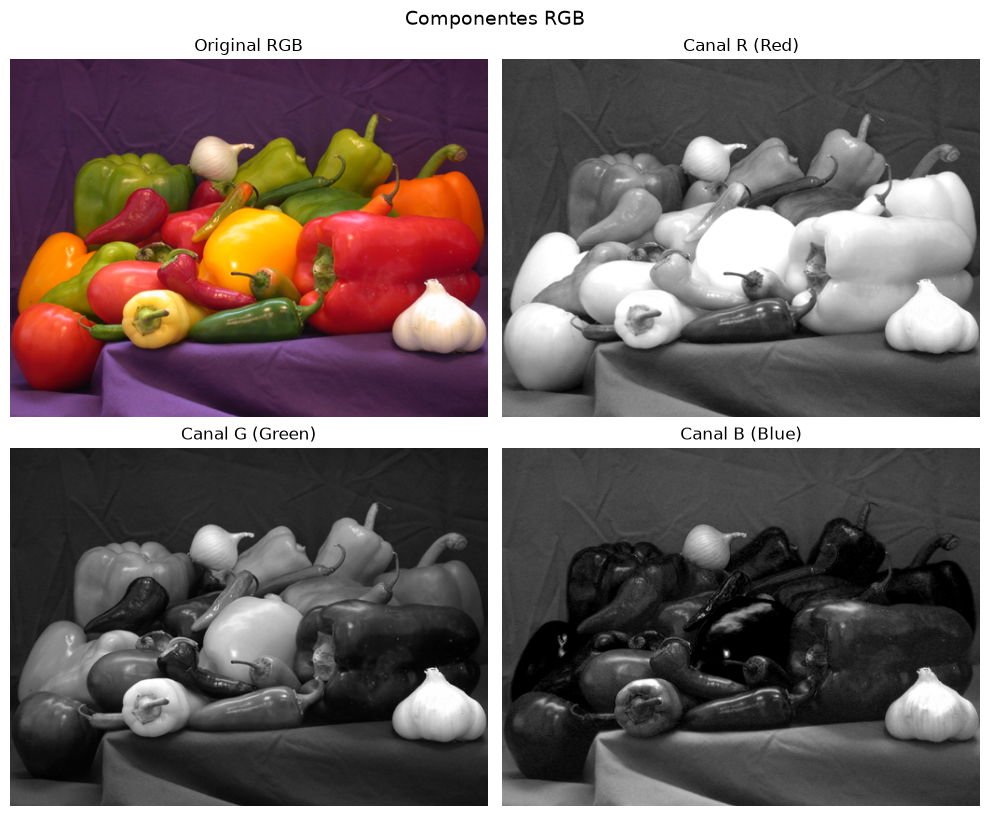

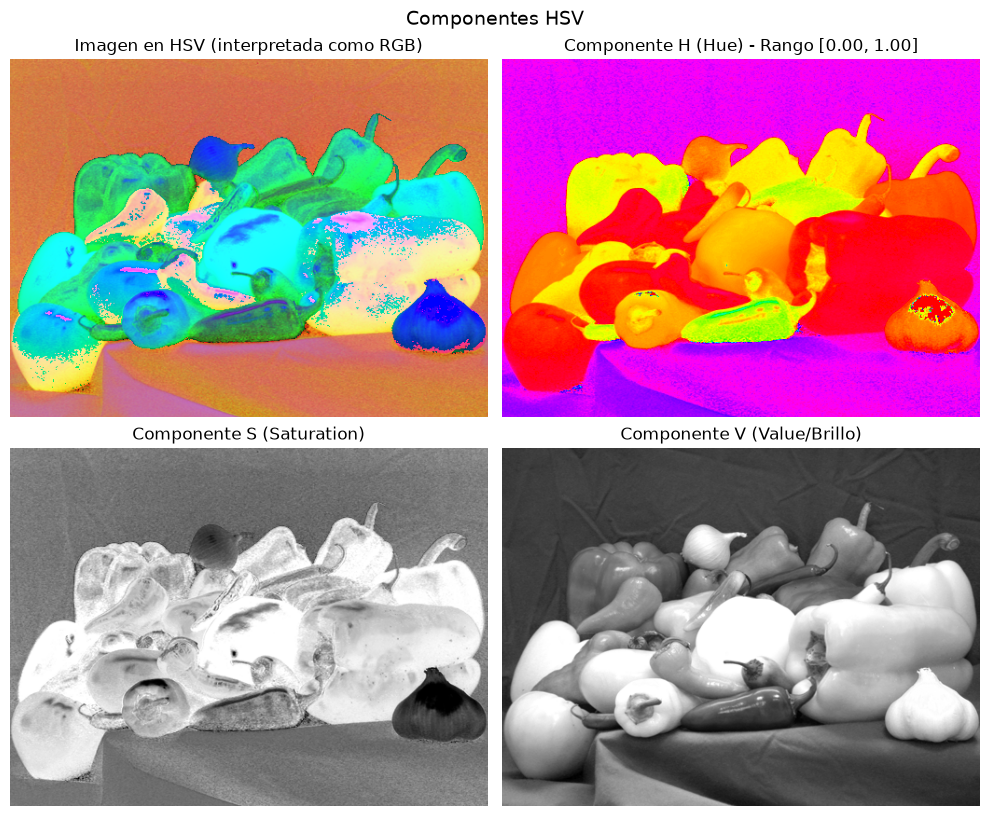

In [4]:
from skimage import color

# 1. Leer imagen peppers.png nuevamente
img_peppers = io.imread('peppers.png')
if img_peppers.ndim == 3 and img_peppers.shape[2] == 4:
    img_peppers = img_peppers[:, :, :3]

# 2. Convertir de RGB a HSV usando skimage.color
peppers_hsv = color.rgb2hsv(img_peppers)

# Extraer componentes individuales de HSV
H = peppers_hsv[:, :, 0]
S = peppers_hsv[:, :, 1]
V = peppers_hsv[:, :, 2]

# --- FIGURA 1: CANALES RGB ---
fig1, axes1 = plt.subplots(2, 2, figsize=(10, 8))

axes1[0, 0].imshow(img_peppers)
axes1[0, 0].set_title('Original RGB')
axes1[0, 0].axis('off')

axes1[0, 1].imshow(img_peppers[:, :, 0], cmap='gray')
axes1[0, 1].set_title('Canal R (Red)')
axes1[0, 1].axis('off')

axes1[1, 0].imshow(img_peppers[:, :, 1], cmap='gray')
axes1[1, 0].set_title('Canal G (Green)')
axes1[1, 0].axis('off')

axes1[1, 1].imshow(img_peppers[:, :, 2], cmap='gray')
axes1[1, 1].set_title('Canal B (Blue)')
axes1[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Componentes RGB', fontsize=14, y=1.02)
plt.show()

# --- FIGURA 2: CANALES HSV ---
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

axes2[0, 0].imshow(peppers_hsv) # Matplotlib no interpreta HSV directamente en imshow, se verá extraño
axes2[0, 0].set_title('Imagen en HSV (interpretada como RGB)')
axes2[0, 0].axis('off')

axes2[0, 1].imshow(H, cmap='hsv') # Usamos el mapa de color 'hsv' para visualizar tonos
axes2[0, 1].set_title(f'Componente H (Hue) - Rango [{H.min():.2f}, {H.max():.2f}]')
axes2[0, 1].axis('off')

axes2[1, 0].imshow(S, cmap='gray')
axes2[1, 0].set_title('Componente S (Saturation)')
axes2[1, 0].axis('off')

axes2[1, 1].imshow(V, cmap='gray')
axes2[1, 1].set_title('Componente V (Value/Brillo)')
axes2[1, 1].axis('off')

plt.tight_layout()
plt.suptitle('Componentes HSV', fontsize=14, y=1.02)
plt.show()

## 2.2

# 3. HISTOGRAMS

# 4. HISTOGRAM EQUALIZATION

## 4.1

## 4.2

# 5.1 FILTERS

# 5.2 HIGH-PASS FILTERS

## 5.2.1

## 5.2.2

## 5.2.3

# 5.3 MEDIAN FILTER